In [1]:
import os
import sys

sys.path.append("..")

import numpy as np

import ssptools
from astropy.coordinates import SkyCoord

from fink_utils.sso.spins import cos_aspect_angle, rotation_phase, subobserver_longitude

from sbpy.photometry import HG1G2

import matplotlib.pyplot as plt

import rocks

In [ ]:
# G1G2 function
def func_g(ph, g1, g2):

    func1 = (
        g1 * HG1G2._phi1(ph) + g2 * HG1G2._phi2(ph) + (1 - g1 - g2) * HG1G2._phi3(ph)
    )
    func1 = -2.5 * np.log10(func1)
    return func1


# Function to calculate the area of the light curve
def func_area(pha, ra0, dec0, period, phi0, a_b, a_c, t0, mode="eQe"):

    ep = pha[3]

    match mode:
        case "eQe":
            ra = pha[1]
            dec = pha[2]

        case "sQs":
            ra = pha[4]
            dec = pha[5]

        case "eQs":
            ra = pha[1]
            dec = pha[2]
            ra_s = pha[4]
            dec_s = pha[5]

    # Rotation
    W = rotation_phase(ep, phi0, 2 * np.pi / period, t0)

    # SEP Coordinates
    cos_aspect = cos_aspect_angle(ra, dec, ra0, dec0)
    sin_aspect = np.sqrt(1 - cos_aspect**2)
    rot_phase = subobserver_longitude(ra, dec, ra0, dec0, W)

    # SSP Coordinates
    if mode == "eQs":
        cos_aspect_s = cos_aspect_angle(ra_s, dec_s, ra0, dec0)
        sin_aspect_s = np.sqrt(1 - cos_aspect_s**2)
        rot_phase_s = subobserver_longitude(ra_s, dec_s, ra0, dec0, W)

        func = (
            sin_aspect * np.cos(rot_phase) * sin_aspect_s * np.cos(rot_phase_s)
            + sin_aspect
            * np.sin(rot_phase)
            * sin_aspect_s
            * np.sin(rot_phase_s)
            * (a_b**2)
            + cos_aspect * cos_aspect_s * a_c**2
        )

    else:
        cos_aspect_2 = cos_aspect**2
        sin_aspect_2 = 1 - cos_aspect_2
        func = (
            sin_aspect_2 * (np.cos(rot_phase) ** 2 + (a_b**2) * np.sin(rot_phase) ** 2)
            + cos_aspect_2 * a_c**2
        )

    return func

In [69]:
target = 22

sc = rocks.Rock(target)
ra0 = sc.spin[0].RA0.value
dec0 = sc.spin[0].DEC0.value
period = sc.spin[0].period.value / 24

a_b, a_c = 1.0, 1.5
G1, G2 = 0.8, 0.05

nbd = 1000
step = 1

In [47]:
eph = ssptools.ephemcc(target, "now", nbd, step, observer="500")
eph_s = ssptools.ephemcc(target, "now", nbd, step, observer="@Sun")

coord = SkyCoord(eph["RA"], eph["DEC"], unit=("hour", "deg"))
eph["ra_deg"] = coord.ra.deg
eph["dec_deg"] = coord.dec.deg
eph["ra_rad"] = np.radians(eph["ra_deg"])
eph["dec_rad"] = np.radians(eph["dec_deg"])
eph["ph"] = np.radians(eph["Phase"])

coord_s = SkyCoord(eph_s["RA"], eph_s["DEC"], unit=("hour", "deg"))
eph_s["ra_deg"] = coord_s.ra.deg
eph_s["dec_deg"] = coord_s.dec.deg
eph_s["ra_rad"] = np.radians(eph_s["ra_deg"])
eph_s["dec_rad"] = np.radians(eph_s["dec_deg"])

data_all = np.vstack(
    [
        eph["ph"],
        eph["ra_rad"],
        eph["dec_rad"],
        eph["Date"],
        eph_s["ra_rad"],
        eph_s["dec_rad"],
    ]
)

In [70]:
S_eQe = func_area(data_all, ra0, dec0, period, 0, a_b, a_c, 2460814, mode="eQe")
S_sQs = func_area(data_all, ra0, dec0, period, 0, a_b, a_c, 2460814, mode="sQs")
S_eQs = func_area(data_all, ra0, dec0, period, 0, a_b, a_c, 2460814, mode="eQs")

g = func_g(eph["ph"], G1, G2)

area1 = np.sqrt(S_eQe)
area2 = S_eQs / np.sqrt(S_sQs)

s1 = -2.5 * np.log10(area1)
s2 = -2.5 * np.log10((area1 + area2) / 2)

/tmp/ipykernel_17381/2561086561.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


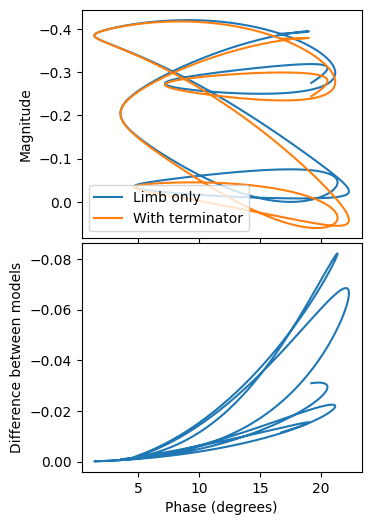

In [71]:
fig, ax = plt.subplots(2, 1, figsize=(4, 6), sharex=True,
                       gridspec_kw={"hspace": 0.02, 'left': 0.20, })

ax[0].plot(eph["Phase"], s1, label="Limb only")
ax[0].plot(eph["Phase"], s2, label="With terminator")

ax[1].plot(eph["Phase"], s1 - s2)

for a in ax:
    a.set_xlabel("Phase (degrees)")
    a.invert_yaxis()
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Difference between models")

ax[0].legend(loc='lower left')
fig.tight_layout()

fig.savefig('limb_vs_terminator.png', dpi=300, facecolor='white')